# 🩺 Diabetes Prediction - Sprint 3
## Advanced Optimization & Explainable AI

**Building on Sprint 2:** Now we add carbon footprint tracking, optimize for the right metric, and make the model explainable.

---

## Table of Contents

1. [Setup & Data](#1)
2. [Carbon Footprint + Architecture Selection](#2)
3. [Metric Selection & Why Recall Matters](#3)
4. [Class Imbalance Handling](#4)
5. [Threshold Optimization](#5)
6. [Enhanced Model with Regularization](#6)
7. [Explainable AI (SHAP & LIME)](#7)
8. [Final Evaluation & Summary](#8)

---
## 1. Setup & Data <a name="1"></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC
from tensorflow.keras.regularizers import l2

# Metrics
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, 
    classification_report, f1_score, recall_score, precision_score
)

# Carbon tracking
from codecarbon import EmissionsTracker

# Explainability
import shap
import lime.lime_tabular

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print("✓ All imports ready!")

TensorFlow: 2.21.0
✓ All imports ready!


In [7]:
# Load data from Sprint 1
X_train = pd.read_csv('X_train_scaled.csv')
X_val = pd.read_csv('X_val_scaled.csv')
X_test = pd.read_csv('X_test_scaled.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_val = pd.read_csv('y_val.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

feature_names = X_train.columns.tolist()
n_features = X_train.shape[1]

# Class imbalance info
n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
class_weight = {0: 1.0, 1: n_neg / n_pos}

print(f"Data: {X_train.shape[0]:,} train | {X_val.shape[0]:,} val | {X_test.shape[0]:,} test")
print(f"Features: {n_features}")
print(f"Class imbalance: {n_neg:,} vs {n_pos:,} ({n_neg/n_pos:.1f}:1)")

Data: 177,576 train | 38,052 val | 38,052 test
Features: 19
Class imbalance: 152,834 vs 24,742 (6.2:1)


---
## 2. Carbon Footprint + Architecture Selection <a name="2"></a>

### What is CodeCarbon?

**CodeCarbon** tracks the CO₂ emissions of the code by measuring energy consumption and converting it using regional carbon intensity.

```
CO₂ (kg) = Energy (kWh) × Carbon Intensity (kg CO₂/kWh)
```

Now the architecture chosen will be the one with the **best balance of performance AND sustainability**.

In [8]:
def build_model(architecture, input_dim):
    """Build MLP with given architecture (list of neurons per layer)."""
    model = Sequential([Input(shape=(input_dim,))])
    
    for i, neurons in enumerate(architecture):
        model.add(Dense(neurons, activation='relu'))
        if i < len(architecture) - 1:
            model.add(Dropout(0.3))
    
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=[AUC(name='auc')])
    return model

In [9]:
# Same 16 architectures from Sprint 2
architectures = {
    '1L_16': [16], '1L_32': [32], '1L_64': [64], '1L_128': [128],
    '2L_32-8': [32,8], '2L_32-16': [32,16], '2L_64-32': [64,32], '2L_128-64': [128,64],
    '3L_32-16-4': [32,16,4], '3L_32-16-8': [32,16,8], '3L_64-32-16': [64,32,16], '3L_128-64-32': [128,64,32],
    '4L_32-16-8-2': [32,16,8,2], '4L_32-16-8-4': [32,16,8,4], '4L_64-32-16-8': [64,32,16,8], '4L_128-64-32-16': [128,64,32,16]
}

print(f"Testing {len(architectures)} architectures with carbon tracking...")

Testing 16 architectures with carbon tracking...


In [10]:
# Run experiment with carbon tracking
early_stop = EarlyStopping(monitor='val_auc', patience=10, mode='max', restore_best_weights=True, verbose=0)
results = []

for name, arch in architectures.items():
    tracker = EmissionsTracker(log_level='error', save_to_file=False)
    tracker.start()
    start = time.time()
    
    model = build_model(arch, n_features)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50, batch_size=256,
        class_weight=class_weight,
        callbacks=[early_stop],
        verbose=0
    )
    
    emissions = tracker.stop() or 0
    train_time = time.time() - start
    val_auc = roc_auc_score(y_val, model.predict(X_val, verbose=0).ravel())
    
    results.append({
        'Architecture': name, 'Layers': arch, 'Params': model.count_params(),
        'Val_AUC': val_auc, 'Time_s': train_time, 'CO2_g': emissions * 1000
    })
    print(f"{name:20} | AUC: {val_auc:.4f} | Time: {train_time:5.1f}s | CO₂: {emissions*1000:.4f}g")

print("\n✓ Done!")

1L_16                | AUC: 0.8265 | Time:  77.8s | CO₂: 0.0148g
1L_32                | AUC: 0.8201 | Time:  16.9s | CO₂: 0.0032g
1L_64                | AUC: 0.8235 | Time:  19.4s | CO₂: 0.0042g
1L_128               | AUC: 0.8251 | Time:  18.7s | CO₂: 0.0035g
2L_32-8              | AUC: 0.8194 | Time:  20.3s | CO₂: 0.0038g
2L_32-16             | AUC: 0.8200 | Time:  19.3s | CO₂: 0.0035g
2L_64-32             | AUC: 0.8227 | Time:  23.9s | CO₂: 0.0046g
2L_128-64            | AUC: 0.8250 | Time:  23.5s | CO₂: 0.0043g
3L_32-16-4           | AUC: 0.8187 | Time:  21.2s | CO₂: 0.0039g
3L_32-16-8           | AUC: 0.8179 | Time:  20.9s | CO₂: 0.0039g
3L_64-32-16          | AUC: 0.8224 | Time:  22.9s | CO₂: 0.0043g
3L_128-64-32         | AUC: 0.8239 | Time:  26.7s | CO₂: 0.0049g
4L_32-16-8-2         | AUC: 0.8194 | Time:  23.3s | CO₂: 0.0043g
4L_32-16-8-4         | AUC: 0.8184 | Time:  23.1s | CO₂: 0.0043g
4L_64-32-16-8        | AUC: 0.8220 | Time:  24.1s | CO₂: 0.0044g
4L_128-64-32-16      | AU

In [11]:
# Results table with efficiency score
results_df = pd.DataFrame(results).sort_values('Val_AUC', ascending=False)
results_df['Efficiency'] = results_df['Val_AUC'] / (results_df['CO2_g'] + 0.0001)

print("\n" + "="*80)
print("RESULTS: Sorted by AUC")
print("="*80)
print(results_df[['Architecture', 'Params', 'Val_AUC', 'Time_s', 'CO2_g', 'Efficiency']].to_string(index=False))


RESULTS: Sorted by AUC
   Architecture  Params  Val_AUC    Time_s    CO2_g  Efficiency
          1L_16     337 0.826544 77.770322 0.014806   55.451565
         1L_128    2689 0.825100 18.677730 0.003464  231.520982
      2L_128-64   10881 0.825032 23.451281 0.004318  186.740195
   3L_128-64-32   12929 0.823895 26.693201 0.004927  163.889598
4L_128-64-32-16   13441 0.823879 29.025510 0.005332  151.666455
          1L_64    1345 0.823475 19.404534 0.004237  189.891552
       2L_64-32    3393 0.822666 23.926332 0.004587  175.526809
    3L_64-32-16    3905 0.822447 22.869442 0.004291  187.281949
  4L_64-32-16-8    4033 0.821953 24.053611 0.004396  182.808271
          1L_32     673 0.820082 16.933530 0.003207  247.963875
       2L_32-16    1185 0.820018 19.318458 0.003529  225.984003
   4L_32-16-8-2    1325 0.819421 23.252312 0.004301  186.174202
        2L_32-8     913 0.819373 20.269607 0.003780  211.199842
     3L_32-16-4    1241 0.818659 21.181594 0.003869  206.266389
   4L_32-16-8-4 

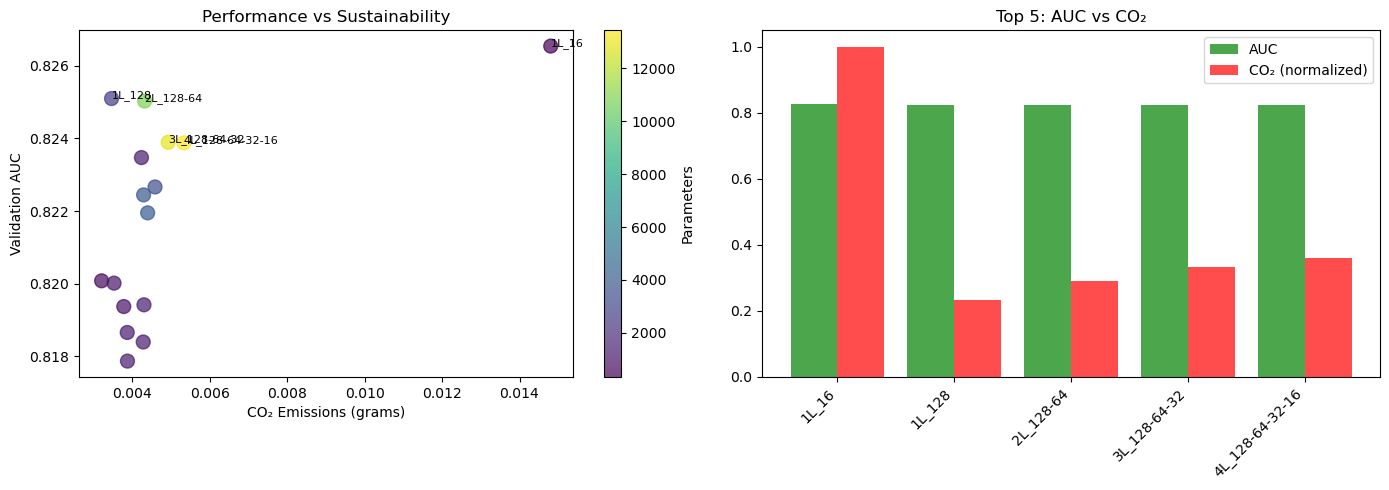

In [12]:
# Visualize: AUC vs CO2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
scatter = axes[0].scatter(results_df['CO2_g'], results_df['Val_AUC'], 
                          c=results_df['Params'], cmap='viridis', s=100, alpha=0.7)
axes[0].set_xlabel('CO₂ Emissions (grams)')
axes[0].set_ylabel('Validation AUC')
axes[0].set_title('Performance vs Sustainability')
plt.colorbar(scatter, ax=axes[0], label='Parameters')
for _, row in results_df.head(5).iterrows():
    axes[0].annotate(row['Architecture'], (row['CO2_g'], row['Val_AUC']), fontsize=8)

# Bar chart comparison
top5 = results_df.head(5)
x = np.arange(len(top5))
axes[1].bar(x - 0.2, top5['Val_AUC'], 0.4, label='AUC', color='green', alpha=0.7)
axes[1].bar(x + 0.2, top5['CO2_g'] / top5['CO2_g'].max(), 0.4, label='CO₂ (normalized)', color='red', alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(top5['Architecture'], rotation=45, ha='right')
axes[1].set_title('Top 5: AUC vs CO₂')
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Manual selection based on analysis
SELECTED_ARCH = '1L_128'
SELECTED_LAYERS = [128]

print(f"✅ SELECTED: {SELECTED_ARCH} (manual choice - best performance/efficiency balance)")

✅ SELECTED: 1L_128 (manual choice - best performance/efficiency balance)


---
## 3. Metric Selection & Why Recall Matters <a name="3"></a>

### Clinical Context

| Error Type | Consequence |
|------------|-------------|
| **False Negative** (miss diabetic) | Untreated → blindness, kidney failure, death |
| **False Positive** (false alarm) | Extra blood test → minor inconvenience |

**Conclusion: Missing a diabetic is far worse → PRIORITIZE RECALL**

In [19]:
print("="*70)
print("3. METRIC SELECTION")
print("="*70)
print("""
CLINICAL DECISION:
  • Missing a diabetic → serious harm (blindness, death)
  • False alarm → minor inconvenience ($20 blood test)
  
THEREFORE: Prioritize RECALL (catch diabetics)

METRIC HIERARCHY:
  1. ROC-AUC   → Overall model quality
  2. Recall    → Clinical priority (catch diabetics)
  3. F1-Score  → Balance check
  4. Precision → Monitor false alarm rate
""")

3. METRIC SELECTION

CLINICAL DECISION:
  • Missing a diabetic → serious harm (blindness, death)
  • False alarm → minor inconvenience ($20 blood test)
  
THEREFORE: Prioritize RECALL (catch diabetics)

METRIC HIERARCHY:
  1. ROC-AUC   → Overall model quality
  2. Recall    → Clinical priority (catch diabetics)
  3. F1-Score  → Balance check
  4. Precision → Monitor false alarm rate



---
## 4. Class Imbalance Handling <a name="4"></a>

**Our approach:** Class weights only (NO synthetic data like SMOTE)

**Why no SMOTE?** Medical data should use real patients only. Synthetic patients may have impossible feature combinations.

In [20]:
print("="*70)
print("4. CLASS IMBALANCE HANDLING")
print("="*70)
print(f"\nClass Distribution: {n_neg:,} (No Diabetes) vs {n_pos:,} (Diabetes) = {n_neg/n_pos:.1f}:1")
print(f"\nClass Weights: {{0: 1.0, 1: {class_weight[1]:.2f}}}")
print(f"→ Misclassifying a diabetic costs {class_weight[1]:.1f}x more")
print(f"\n NOT using SMOTE: Medical data requires real patients only")

4. CLASS IMBALANCE HANDLING

Class Distribution: 152,834 (No Diabetes) vs 24,742 (Diabetes) = 6.2:1

Class Weights: {0: 1.0, 1: 6.18}
→ Misclassifying a diabetic costs 6.2x more

 NOT using SMOTE: Medical data requires real patients only


---
## 5. Threshold Optimization <a name="5"></a>

Default threshold (0.5) may not be optimal. We find the threshold that maximizes Recall while keeping Precision acceptable.

In [21]:
# Train selected architecture
print(f"Training: {SELECTED_ARCH}")
base_model = build_model(SELECTED_LAYERS, n_features)

history = base_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50, batch_size=256,
    class_weight=class_weight,
    callbacks=[EarlyStopping(monitor='val_auc', patience=10, mode='max', restore_best_weights=True, verbose=0)],
    verbose=1
)

y_val_proba = base_model.predict(X_val, verbose=0).ravel()
print(f"\n✓ Val AUC: {roc_auc_score(y_val, y_val_proba):.4f}")

Training: 1L_128
Epoch 1/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - auc: 0.8201 - loss: 0.8870 - val_auc: 0.8247 - val_loss: 0.5249
Epoch 2/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - auc: 0.8282 - loss: 0.8687 - val_auc: 0.8257 - val_loss: 0.5239
Epoch 3/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - auc: 0.8292 - loss: 0.8665 - val_auc: 0.8259 - val_loss: 0.5243
Epoch 4/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8297 - loss: 0.8654 - val_auc: 0.8260 - val_loss: 0.5245
Epoch 5/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8301 - loss: 0.8645 - val_auc: 0.8261 - val_loss: 0.5246
Epoch 6/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8304 - loss: 0.8639 - val_auc: 0.8261 - val_loss: 0.5246
Epoch 7/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8306 - loss: 0.8633 - val_auc: 0.8261 - val_loss: 0.5247
Epoch 8/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8308 - loss: 0.8629 - val_auc: 0.8260 - val_loss: 0.5247
Epoch 9/50
694/694 ━━━━━━━━━━━━━━━━━━━━

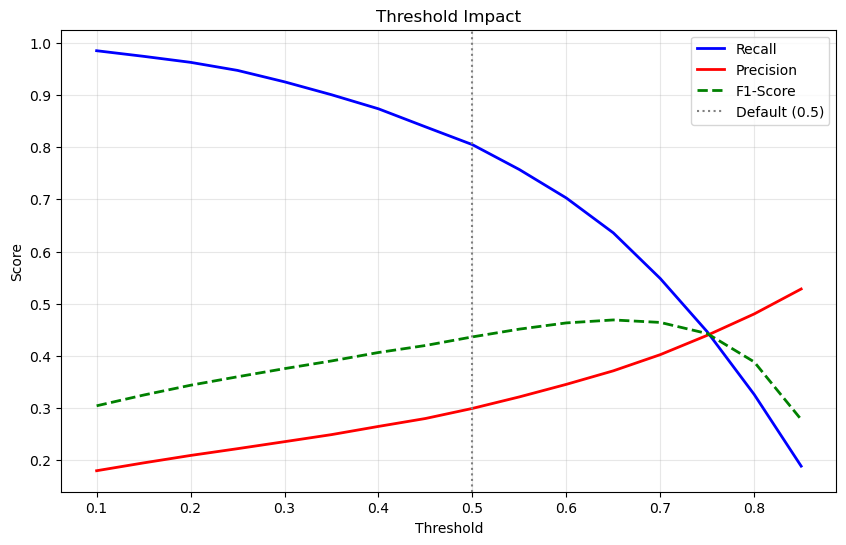

 Threshold   Recall  Precision       F1
      0.10 0.984723   0.180034 0.304414
      0.15 0.973972   0.195045 0.325005
      0.20 0.962467   0.209294 0.343822
      0.25 0.947001   0.222266 0.360032
      0.30 0.925123   0.235670 0.375646
      0.35 0.900415   0.249191 0.390352
      0.40 0.873444   0.264916 0.406531
      0.45 0.838929   0.280065 0.419940
      0.50 0.804791   0.299397 0.436432
      0.55 0.757073   0.321480 0.451315
      0.60 0.702565   0.345515 0.463222
      0.65 0.635798   0.371419 0.468911
      0.70 0.548284   0.402409 0.464155
      0.75 0.446247   0.439450 0.442822
      0.80 0.326103   0.480411 0.388496
      0.85 0.188797   0.528232 0.278171


In [22]:
# Threshold analysis
thresholds = np.arange(0.1, 0.9, 0.05)
thresh_df = pd.DataFrame([{
    'Threshold': t,
    'Recall': recall_score(y_val, (y_val_proba >= t).astype(int)),
    'Precision': precision_score(y_val, (y_val_proba >= t).astype(int), zero_division=0),
    'F1': f1_score(y_val, (y_val_proba >= t).astype(int))
} for t in thresholds])

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresh_df['Threshold'], thresh_df['Recall'], 'b-', label='Recall', linewidth=2)
plt.plot(thresh_df['Threshold'], thresh_df['Precision'], 'r-', label='Precision', linewidth=2)
plt.plot(thresh_df['Threshold'], thresh_df['F1'], 'g--', label='F1-Score', linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle=':', label='Default (0.5)')
plt.xlabel('Threshold'); plt.ylabel('Score'); plt.title('Threshold Impact')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

print(thresh_df.to_string(index=False))

In [35]:
# Select optimal: Max Recall where Precision >= 0.24
valid = thresh_df[thresh_df['Precision'] >= 0.24]
best_row = valid.loc[valid['Recall'].idxmax()] if len(valid) > 0 else thresh_df.loc[thresh_df['F1'].idxmax()]
OPTIMAL_THRESHOLD = best_row['Threshold']

print(f"\n OPTIMAL THRESHOLD: {OPTIMAL_THRESHOLD:.2f}")
print(f"   Recall: {best_row['Recall']:.4f} | Precision: {best_row['Precision']:.4f} | F1: {best_row['F1']:.4f}")


 OPTIMAL THRESHOLD: 0.35
   Recall: 0.9004 | Precision: 0.2492 | F1: 0.3904


---
## 6. Enhanced Model with Regularization <a name="6"></a>

Enhancements: BatchNorm + L2 Regularization + LeakyReLU + LR Scheduling

In [24]:
def build_enhanced_model(architecture, input_dim, l2_strength=0.001):
    """Enhanced model with BatchNorm, L2, and LeakyReLU."""
    model = Sequential([Input(shape=(input_dim,))])
    
    for i, neurons in enumerate(architecture):
        model.add(Dense(neurons, kernel_regularizer=l2(l2_strength)))
        model.add(BatchNormalization())
        model.add(LeakyReLU(negative_slope=0.1))
        if i < len(architecture) - 1:
            model.add(Dropout(0.3))
    
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=[AUC(name='auc')])
    return model

In [25]:
# Train enhanced model
print("Training ENHANCED model...")
enhanced_model = build_enhanced_model(SELECTED_LAYERS, n_features)
enhanced_model.summary()

callbacks = [
    EarlyStopping(monitor='val_auc', patience=15, mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5, mode='max', verbose=1)
]

history_enhanced = enhanced_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=256,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

Training ENHANCED model...


Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_116 (Dense)               │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/100
694/694 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - auc: 0.8189 - loss: 0.9159 - val_auc: 0.8236 - val_loss: 0.5454 - learning_rate: 0.0010
Epoch 2/100
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8260 - loss: 0.8923 - val_auc: 0.8241 - val_loss: 0.5399 - learning_rate: 0.0010
Epoch 3/100
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8270 - loss: 0.8859 - val_auc: 0.8244 - val_loss: 0.5364 - learning_rate: 0.0010
Epoch 4/100
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8275 - loss: 0.8821 - val_auc: 0.8247 - val_loss: 0.5347 - learning_rate: 0.0010
Epoch 5/100
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8278 - loss: 0.8794 - val_auc: 0.8249 - val_loss: 0.5341 - learning_rate: 0.0010
Epoch 6/100
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8281 - loss: 0.8776 - val_auc: 0.8250 - val_loss: 0.5343 - learning_rate: 0.0010
Epoch 7/100
694/694 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc: 0.8282 - loss: 0.8762 - val_auc: 0.8251 - val_loss: 0.5336 - learning_rate: 0.0010

In [26]:
# Compare
y_val_proba_enhanced = enhanced_model.predict(X_val, verbose=0).ravel()
base_auc = roc_auc_score(y_val, y_val_proba)
enhanced_auc = roc_auc_score(y_val, y_val_proba_enhanced)

print(f"\n Comparison:")
print(f"   Base:     {base_auc:.4f}")
print(f"   Enhanced: {enhanced_auc:.4f} ({enhanced_auc - base_auc:+.4f})")

final_model = enhanced_model if enhanced_auc >= base_auc else base_model
print(f"\n Using {'ENHANCED' if enhanced_auc >= base_auc else 'BASE'} model")


 Comparison:
   Base:     0.8261
   Enhanced: 0.8270 (+0.0008)

 Using ENHANCED model


---
## 7. Explainable AI (SHAP & LIME) <a name="7"></a>

**SHAP:** Shows how each feature contributes to predictions (global + local)

**LIME:** Creates simple explanations for individual predictions

In [27]:
print("="*70)
print("7. EXPLAINABLE AI - SHAP")
print("="*70)

# SHAP explainer (use sample for speed)
X_sample = X_train.sample(n=500, random_state=42)
explainer = shap.KernelExplainer(final_model.predict, X_sample)

# Calculate SHAP values
X_explain = X_test.iloc[:100]
shap_values = explainer.shap_values(X_explain, nsamples=100)
print("✓ SHAP values calculated")

7. EXPLAINABLE AI - SHAP
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Using 500 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/100 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 890us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━

<Figure size 1000x800 with 0 Axes>

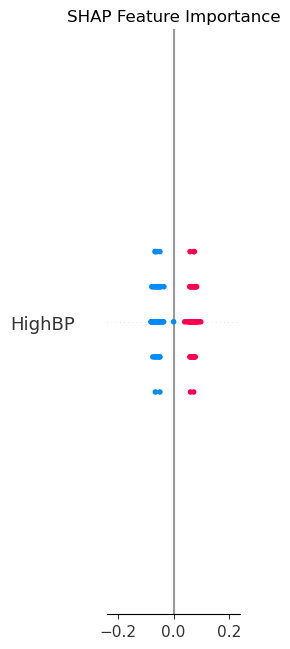

<Figure size 1000x600 with 0 Axes>

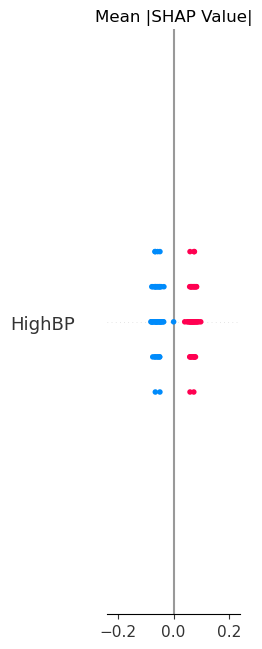

In [34]:
# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_explain, feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout(); plt.show()

# Bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_explain, feature_names=feature_names, plot_type='bar', show=False)
plt.title('Mean |SHAP Value|')
plt.tight_layout(); plt.show()


EXPLAINABLE AI - LIME


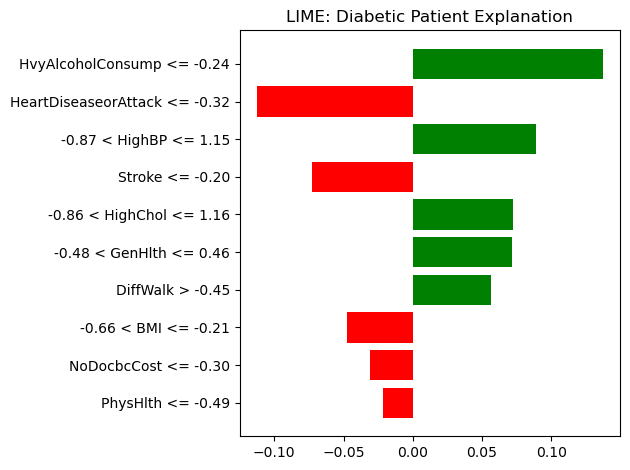


Top features:
   HvyAlcoholConsump <= -0.24: +0.1372
   HeartDiseaseorAttack <= -0.32: -0.1124
   -0.87 < HighBP <= 1.15: +0.0886
   Stroke <= -0.20: -0.0729
   -0.86 < HighChol <= 1.16: +0.0722


In [30]:
print("\n" + "="*70)
print("EXPLAINABLE AI - LIME")
print("="*70)

# LIME needs probabilities for BOTH classes [P(no diabetes), P(diabetes)]
def predict_proba(X):
    prob_diabetes = final_model.predict(X, verbose=0)
    prob_no_diabetes = 1 - prob_diabetes
    return np.hstack([prob_no_diabetes, prob_diabetes])

# LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values, 
    feature_names=feature_names,
    class_names=['No Diabetes', 'Diabetes'], 
    mode='classification'
)

# Explain a diabetic case
diabetic_idx = np.where(y_test == 1)[0][0]
lime_exp = lime_explainer.explain_instance(
    X_test.iloc[diabetic_idx].values, 
    predict_proba,  # Use wrapper, not final_model.predict
    num_features=10
)

lime_exp.as_pyplot_figure()
plt.title('LIME: Diabetic Patient Explanation')
plt.tight_layout()
plt.show()

print("\nTop features:")
for feat, weight in lime_exp.as_list()[:5]:
    print(f"   {feat}: {weight:+.4f}")

---
## 8. Final Evaluation & Summary <a name="8"></a>

8. FINAL EVALUATION

 Test Results (Threshold: 0.35):
   ROC-AUC:   0.8289
   Recall:    0.9038 (90.4% diabetics caught)
   Precision: 0.2570
   F1-Score:  0.4002


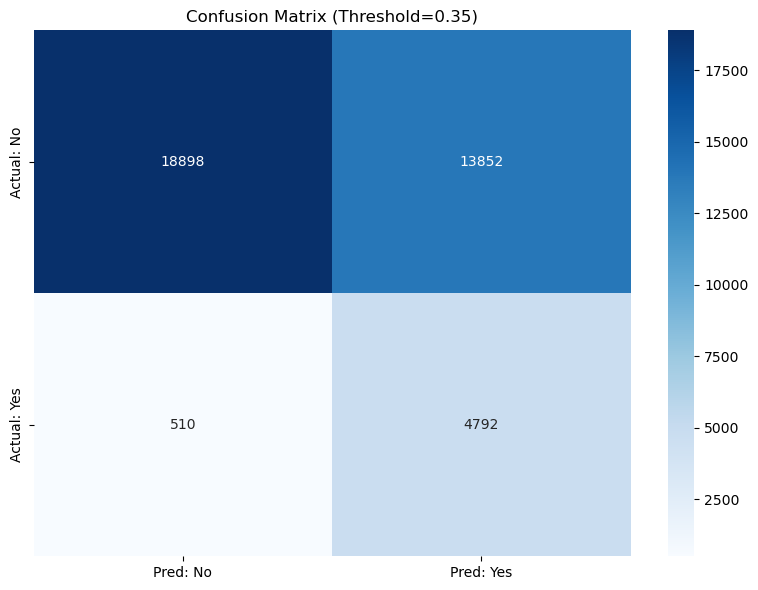


   TP: 4,792 | FN: 510 (missed) | FP: 13,852 | TN: 18,898


In [36]:
print("="*70)
print("8. FINAL EVALUATION")
print("="*70)

# Test predictions
y_test_proba = final_model.predict(X_test, verbose=0).ravel()
y_test_pred = (y_test_proba >= OPTIMAL_THRESHOLD).astype(int)

# Metrics
test_auc = roc_auc_score(y_test, y_test_proba)
test_recall = recall_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"\n Test Results (Threshold: {OPTIMAL_THRESHOLD:.2f}):")
print(f"   ROC-AUC:   {test_auc:.4f}")
print(f"   Recall:    {test_recall:.4f} ({test_recall*100:.1f}% diabetics caught)")
print(f"   Precision: {test_precision:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No', 'Pred: Yes'], yticklabels=['Actual: No', 'Actual: Yes'])
plt.title(f'Confusion Matrix (Threshold={OPTIMAL_THRESHOLD:.2f})')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n   TP: {tp:,} | FN: {fn:,} (missed) | FP: {fp:,} | TN: {tn:,}")

In [37]:
print("\n" + "="*70)
print("SPRINT 3 SUMMARY")
print("="*70)
print(f"""
1. ARCHITECTURE: {SELECTED_ARCH}
   → Selected using AUC + CO₂ efficiency

2. FRAMEWORK: TensorFlow/Keras
   → Industry standard, good documentation

3. CLASS IMBALANCE: Class Weights ({class_weight[1]:.2f}x)
   → NO SMOTE (medical data = real patients only)

4. METRICS: ROC-AUC (primary), Recall (clinical priority)
   → Missing diabetic >> false alarm

5. THRESHOLD: {OPTIMAL_THRESHOLD:.2f}
   → Maximizes Recall with acceptable Precision

6. ENHANCEMENTS: BatchNorm + L2 + LeakyReLU + LR Scheduling

7. EXPLAINABILITY: SHAP (global) + LIME (local)

8. FINAL RESULTS:
   AUC: {test_auc:.4f} | Recall: {test_recall:.4f} | F1: {test_f1:.4f}
 SPRINT 3 COMPLETE
""")


SPRINT 3 SUMMARY

1. ARCHITECTURE: 1L_128
   → Selected using AUC + CO₂ efficiency

2. FRAMEWORK: TensorFlow/Keras
   → Industry standard, good documentation

3. CLASS IMBALANCE: Class Weights (6.18x)
   → NO SMOTE (medical data = real patients only)

4. METRICS: ROC-AUC (primary), Recall (clinical priority)
   → Missing diabetic >> false alarm

5. THRESHOLD: 0.35
   → Maximizes Recall with acceptable Precision

6. ENHANCEMENTS: BatchNorm + L2 + LeakyReLU + LR Scheduling

7. EXPLAINABILITY: SHAP (global) + LIME (local)

8. FINAL RESULTS:
   AUC: 0.8289 | Recall: 0.9038 | F1: 0.4002
 SPRINT 3 COMPLETE



In [33]:
# Save
final_model.save('diabetes_model_sprint3.keras')
results_df.to_csv('architecture_carbon_comparison.csv', index=False)
print("✓ Model and results saved!")

✓ Model and results saved!
